## CONUS GHCND TXx Extreme-Value Analysis with Generalized Extreme Value Modeling

This notebook fits Generalized Extreme Value (GEV) distributions to the Annual Maximum Daily Temperature (TXx) time series from CONUS GHCND stations. The analysis includes location and scale parameter variations with climate covariates, cross-validation for model assessment, and bootstrap confidence intervals for derived quantities (return levels and parameter changes).

In [192]:
itest='CONUSlite_TXx_GHCND_ij_glostLocSca_extremes_gev_CV_CI'

### Configuration and Environment Setup

Set up test name identifier and configure parallel processing threads for numerical computation.

In [193]:
import os

# Set OMP_NUM_THREADS to 4
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"]="8"

In [194]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
from copy import copy
import geopandas as gpd
from shapely.geometry import Point

In [195]:
import datetime
from matplotlib import cm

In [196]:
import rpy2
from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv


%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [197]:
%R Sys.setenv(OMP_NUM_THREADS = 8)
%R Sys.setenv(OPENBLAS_NUM_THREADS = 8)
%R Sys.setenv(MKL_NUM_THREADS = 8)

1


In [198]:
extRemes = importr("extRemes")
twosamples = importr("twosamples")
dplyr = importr("dplyr")
%R source("R_utils.R")

In [199]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [200]:
import warnings
warnings.filterwarnings('ignore')
%R options( warn = -1 )

### R Integration and Extreme-Value Functions

Define custom R functions for bootstrapped estimation and cross-validation of GEV parameters. The `extremes_bootLS` function generates confidence intervals by resampling time series with replacement, while `cross_validation` partitions data and evaluates model performance on held-out folds.

In [201]:
%%R -w 800 --type=cairo

extremes_bootGE_LS <- function(m_gev,r_df,fevd_options,n,alpha,rp,glost){
   ### Following E.Gilleland 2020.
   ntime <- length(r_df[['TXx']])
   ntime <- length(glost$GLOST)
   fitter <- function(data,...,Fit){
      np <- length(rp)
      RL_q <- array(NA, dim = c(ntime, length(rp),3))
      DiffRL_q <- array(NA, dim = c(length(rp),3))

      data <- data.frame(TXx=data,Fit$cov.data)
      initial_vals <- list(location = mean(data$TXx), scale = sd(data$TXx), shape = 0.1)
      call_fevd <- paste("fevd(TXx, data = data,",fevd_options,")")
      fit <- eval(parse(text = call_fevd))
      ppfit <- tryCatch({summary(fit,silent = TRUE)}, error = function(e){
        return(list(scale=rep(-1, ntime)))
        })
      # Determine expected length of your output vector dynamically
      # Length = 1 (DiffLoc) + 1 (DiffScale) + length(DiffRL) + length(Loc) + length(Scale) + length(RL)
      # This matches: c(DiffLoc, DiffScale, DiffRL, Loc, Scale, RL)
      expected_length <- 1 + 1 + length(rp) + ntime + ntime + (ntime * length(rp))
  
      if (!is.null(ppfit$par)) {
        Loc <- ppfit$par[['mu0']] + ppfit$par[['mu1']]*glost$GLOST
        Scale <- ppfit$par[['sigma0']] + ppfit$par[['sigma1']]*glost$GLOST
        if (length(which(Scale <= 0)) == 0) {
        #Loc <- findpars(fit)$location
        #Scale <- findpars(fit)$scale
        DiffLoc <- Loc[ntime] - Loc[1]
        DiffScale <- Scale[ntime] - Scale[1]
        vfit <- make.qcov(fit,vals=list(mu1=glost$GLOST,sigma1=glost$GLOST))

        RL <- return.level(fit,return.period=rp,qcov=vfit)
        DiffRL <- RL[ntime,] - RL[1,]
        out <- c(DiffLoc,DiffScale,DiffRL,Loc,Scale,RL)
        return(out)
        } else {
          return(rep(NA, expected_length))
        }
      }  else {
      # 2. CRITICAL FIX: If scale is bad, return a vector of NAs instead of NULL
        return(rep(NA, expected_length))

      }
    }
   simphx<-function(size,...,Fit){
            out<-c(rextRemes(Fit,size))
            return(out)
            }
   pboopted<-pbooter(x=r_df$TXx,statistic=fitter,B=n,rmodel=simphx,Fit=m_gev,verbose=FALSE)

   boot_matrix <- pboopted$results
   boot_df <- data.frame(boot_matrix)
   boot_df_cleaned <- boot_df[, colSums(is.na(boot_df)) == 0]
   boot_matrix_cleaned <- data.matrix(boot_df_cleaned)
   pboopted$results <- boot_matrix_cleaned
   #
   res<- ci(pboopted,type="perc",alpha=alpha, na.rm = TRUE)
   res<-res$perc
   #
   Diffloc_q <- cbind(res[1,1],res[1,2],res[1,3])
   Diffsca_q <- cbind(res[2,1],res[2,2],res[2,3])
   DiffRL_q <- cbind(res[3:as.integer(3+length(rp)-1),1],res[3:as.integer(3+length(rp)-1),2],res[3:as.integer(3+length(rp)-1),3])
   #              
   ib <- as.integer(3+length(rp))
   ie <- as.integer(3+length(rp)+ntime-1)
   loc_q <- cbind(res[ib:ie,1],res[ib:ie,2],res[ib:ie,3])

   ib <- as.integer(3+length(rp)+ntime)
   ie <- as.integer(3+length(rp)+ntime*2-1)
   sca_q <- cbind(res[ib:ie,1],res[ib:ie,2],res[ib:ie,3])

   ib <- as.integer(3+length(rp)+ntime*2)
   ie <- as.integer(dim(res)[1])
   RL_q <- cbind(res[ib:ie,1],res[ib:ie,2],res[ib:ie,3])
   #

   return(list(Dloc_q=Diffloc_q,Dsca_q=Diffsca_q,DRL_q=DiffRL_q,loc_q=loc_q,sca_q=sca_q,RL_q=RL_q))
  }

In [202]:
%%R -w 800 --type=cairo
#===============================================================================
#===============================================================================
#===============================================================================
# function to define indices of rows of dataframe that assign observations to splits
# This function was written by Finn Lindgren
# ARGS:
# N: positive integer; (= number of rows of full dataframe)
# K: positive integer; (= number of splits for cross-validation)
# Value/Output: numeric of length N with indices 1,...,K defining random splitting into K subsets
cv_indices_splits <- function(N, K=K){
  split_sizes <-  ceiling((1:K)*N/K) - ceiling((0:(K-1))*N/K)
  sample(rep(1:K, times=split_sizes), size=N, replace=FALSE)
}
#===============================================================================
# function that takes data frame and splits/partitions in to training and test dataframes
# This function was written by Finn Lindgren
# ARGS:
# data: a data frame
# splits: index vector defining the K data splits (as produced by cv_indices_splits)
# k: the index k \in 1:K for the subset to be used as test/validation set
# Value/Output:
# a list with two named elements;
# 1.) Train: training data frame with rows of data in subsets with split index not equal to k
# 2.) Test: test data frame with rows of data in subsets with split index equal to k
cv_split <- function(data, splits, k){
  list(Train =  data[((splits != k)&((splits != 0))),  ,drop=FALSE],
       Test  =  data[splits == k,  ,drop=FALSE][1:length(which(splits==k))-1,])

}
cv_split_modulo <- function(data, K, ik){
  list(Train =  data[c(as.integer(K*(ik-1)+1):as.integer(K*(ik-1)+floor(K/2)),as.integer(K*(ik-1)+1+floor(K/2+1)):as.integer(K*ik)),] ,
       Test  =  data[as.integer(K*(ik-1)+floor(K/2+1)),])
}

cross_validation_na <- function(data_k,k){
    na_vec <- rep(NA,times =length(data_k$Test$time))
    TrainAndTest <- list(mod.scores=data.frame(SE=na_vec,DawSeb=na_vec,CRPS=na_vec))
    scores[[k]] <- cbind(TrainAndTest[[1]], time=data_k$Test$time,split_k = k)
    AIC_cv[k] <- NA
    BIC_cv[k] <- NA
    tests[[k]] <- cbind(data.frame(KS_D=na_vec,KS_pvalue=na_vec,CVM_D=na_vec,CVM_pvalue=na_vec), time=data_k$Test$time, split_k = k)
    return(list(scores=scores, tests=tests, AIC_cv=AIC_cv, BIC_cv=BIC_cv))

}

In [203]:
%%R -w 800 --type=cairo

cross_validation <- function(data,fevd_options,K){

#===============================================================================
# function that calls Mod_Train_Test for all for each of the K splits and collects the results
# ARGS:
# data: full data frame to be split in in to training/test sets
# splits: the splitting indices (as produced by cv_indices_splits)
# formula_list: a list of formulas as required by evgam  
  AIC_cv <- NULL
  BIC_cv <- NULL
  scores <- list()  # note AIC/BIC need dealt with
  tests <- list()
  for(k in 1:K){
    data_k <- cv_split(data=data, splits=splits, k)
    initial_vals <- list(location = mean(data_k$Train[['TXx']]), scale = sd(data_k$Train[['TXx']]), shape = 0.1)
    call_fevd <- paste("fevd(TXx, data = data_k$Train,",fevd_options,")")
    mod <- eval(parse(text = call_fevd))
    ppmod <- tryCatch({summary(mod,silent = TRUE)}, error = function(e){
        return(list(scale=rep(-1, length(data_k$Test$time))))
        })
    if (!is.null(ppmod$par)){
        if (length(ppmod$par)==3){
            location <- rep(ppmod$par[['location']],times =length(data_k$Test$time))
            scale <- rep(ppmod$par[['scale']],times =length(data_k$Test$time))
            shape <- rep(ppmod$par[['shape']],times =length(data_k$Test$time))
        } else if ((length(ppmod$par)==4)){
            location <- ppmod$par[['mu0']]+ppmod$par[['mu1']]*data_k$Test$glost
            scale <- rep(ppmod$par[['scale']],times =length(data_k$Test$time))
            shape <- rep(ppmod$par[['shape']],times =length(data_k$Test$time))
        } else if ((length(ppmod$par)==5)){
            location <- ppmod$par[['mu0']]+ppmod$par[['mu1']]*data_k$Test$glost
            scale <- ppmod$par[['sigma0']]+ppmod$par[['sigma1']]*data_k$Test$glost
            shape <- rep(ppmod$par[['shape']],times =length(data_k$Test$time))
        }  
    
        if (length(which(scale <= 0)) == 0) {
            params <-list(location=location,scale=scale,shape=shape)
            params['cell'] <- 1
            TrainAndTest <- list(mod.scores=GEV_scores(data_k$Test,params), mod.AIC=ppmod$AIC, mod.BIC=ppmod$BIC)
    
            scores[[k]] <- cbind(TrainAndTest[[1]], time=data_k$Test$time,split_k = k)
            AIC_cv[k] <- TrainAndTest[[2]]
            BIC_cv[k] <- TrainAndTest[[3]]
            tests[[k]] <- cbind(KS_CVM(data_k$Test,params), time=data_k$Test$time, split_k = k)
        } else {
            res <- cross_validation_na(data_k,k)
            scores<-res$scores
            tests<-res$tests
            AIC_cv<-res$AIC_cv 
            BIC_cv<-res$BIC_cv
        }
    } else {
            res <- cross_validation_na(data_k,k)
            scores<-res$scores
            tests<-res$tests
            AIC_cv<-res$AIC_cv 
            BIC_cv<-res$BIC_cv 
    }
  }
scores <- do.call(rbind, scores)
tests <- do.call(rbind, tests)
list(scores_cv=scores, tests_cv=tests, AIC_cv=AIC_cv, BIC_cv=BIC_cv)
  
}

In [204]:
def find_nearest_valid(arr, lon, lat, radius=1):
    """Find the nearest valid value in a dataset for a given variable and coordinates."""
    # Select a subset of points within a certain radius
    subset = arr.sel(lon=slice(lon-radius, lon+radius), lat=slice(lat-radius, lat+radius))
    # Calculate the Euclidean distance to the points in the subset
    dist = np.sqrt((subset.lon - lon)**2 + (subset.lat - lat)**2)
    # Create a new dataset that only includes valid values
    valid_subset = subset.where(~np.isnan(subset), drop=True)
    # Find the coordinates of the valid point with the smallest distance
    min_dist_coords = dist.where(dist == dist.where(~np.isnan(valid_subset)).min(), drop=True)
    nearest_lon = min_dist_coords.lon.values.item()
    nearest_lat = min_dist_coords.lat.values.item()
    # Select the nearest valid value
    nearest = valid_subset.sel(lon=nearest_lon, lat=nearest_lat)
    return nearest.to_dataframe().reset_index()
    arr_series = arr.sel(lon=lon, lat=lat,method="nearest").to_dataframe().reset_index()

### Data Loading

Load Annual Maximum Daily Temperature (TXx) from GHCND stations, ERA5-derived TXx for spatial comparison, GLOST climate covariates, and geographic data defining the Washington analysis domain.

In [205]:
Tstations = ['USC00452675','USC00456534','USC00045933','USC00046074','USC00028619','USC00025924','USC00307134','USC00306774']
Tstates = ['WA','WA', 'CA', 'CA','AZ','AZ','NY','NY']

In [206]:
yearb = 1979
yeare = 2025
time = np.arange(yearb, yeare + 1, 1)

lon_min = 236
lon_max = 295
lat_min = 22
lat_max = 50

In [207]:
elevation = xr.DataArray(np.zeros((len(Tstations),)), coords=[Tstations], dims=["station"])
longitude = xr.DataArray(np.zeros((len(Tstations),)), coords=[Tstations], dims=["station"])
latitude = xr.DataArray(np.zeros((len(Tstations),)), coords=[Tstations], dims=["station"])
name = xr.DataArray(np.zeros((len(Tstations),)).astype('U100'), coords=[Tstations], dims=["station"])
TXx = xr.DataArray(np.zeros((len(Tstations),len(time))), coords=[Tstations, time], dims=["station", "time"])

In [208]:
for istation, state in zip(Tstations, Tstates):
    print(f'Processing station: {istation} in state: {state}')
    ifile=f'~/data/TXx/GHCND_TXx_utils_{state}.nc'
    ds = xr.open_dataset(ifile)
    TXx.loc[{'station':istation}] = ds['TXx'].sel(station=istation,time=time)
    name.loc[{'station':istation}] = ds['name'].sel(station=istation)
    elevation.loc[{'station':istation}] = ds['elevation'].sel(station=istation)
    longitude.loc[{'station':istation}] = ds['longitude'].sel(station=istation)
    latitude.loc[{'station':istation}] = ds['latitude'].sel(station=istation)
units='°C'

Processing station: USC00452675 in state: WA
Processing station: USC00456534 in state: WA
Processing station: USC00045933 in state: CA
Processing station: USC00046074 in state: CA
Processing station: USC00028619 in state: AZ
Processing station: USC00025924 in state: AZ
Processing station: USC00307134 in state: NY
Processing station: USC00306774 in state: NY


In [209]:
ds = TXx.to_dataset(name='TXx')
ds = ds.merge({'name': name, 'elevation': elevation, 'longitude': longitude, 'latitude': latitude})

In [210]:
ifile=f'~/data/TXx/NorthAmerica_TXx_ij_glostLocSca_extremes_gev_CV_CI300_1979_2025.nc'
dse = xr.open_dataset(ifile)
dse = dse.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
dse['lon'] = dse['lon']-360
locationERA5 = dse['location']
scaleERA5 = dse['scale']
shapeERA5 = dse['shape']

valid_locationERA5 = locationERA5.mean('time').where(locationERA5.mean('time').notnull(), drop=True)
valid_scaleERA5 = scaleERA5.mean('time').where(scaleERA5.mean('time').notnull(), drop=True)
valid_shapeERA5 = shapeERA5.mean('time').where(shapeERA5.mean('time').notnull(), drop=True)

In [211]:
era5lsm = xr.open_dataset('~/data/ERA5/era5_lsmask.nc')
era5lsm =era5lsm.rename({'longitude':'lon', 'latitude':'lat'})
era5lsm = era5lsm.sortby('lat')
era5lsm = era5lsm.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max)).isel(time=0,drop=True) 
era5lsm['lon'] = era5lsm['lon']-360

In [212]:
era5hgt = xr.open_dataset('~/data/ERA5/ERA5_hgt.sfc.nc')
era5hgt = era5hgt.sortby('lat')
era5hgt = era5hgt.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max)).isel(time=0,drop=True) 
era5hgt['lon'] = era5hgt['lon']-360


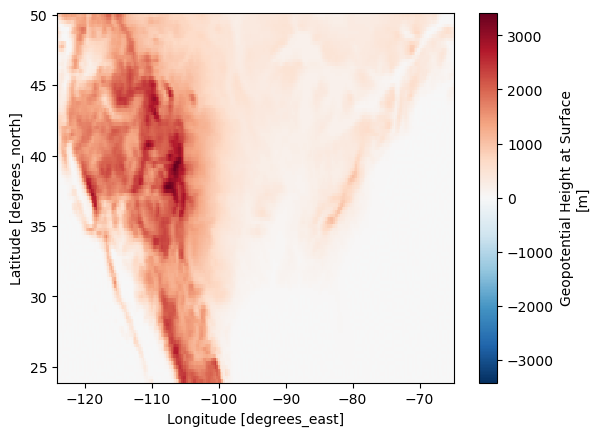

In [213]:
era5hgt['hgt'].plot()

In [233]:

ifile='~/data/TXx/AnnualMaximumDailyTmax.era5.1941.2025.nc4'
dsae = xr.open_dataset(ifile)
dsae = dsae.sel(time=slice(yearb,yeare))
dsae = dsae.sortby('lat')
dsae = dsae.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
dsae['lon'] = dsae['lon']-360
dsae['time'] = np.arange(yearb,yeare+1,1)
dsae = dsae.where(era5lsm['LSM']>=0.5)
units = 'K'

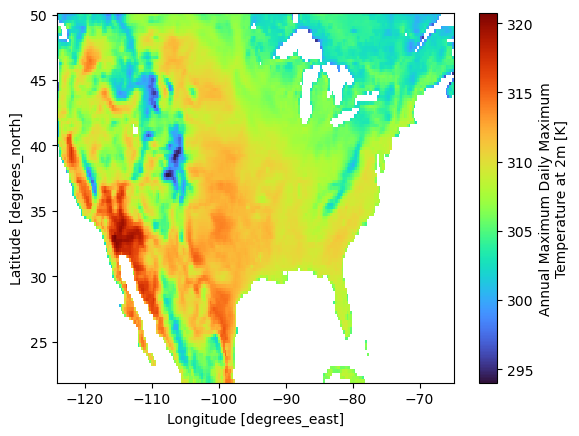

In [234]:
dsae['TXx'].mean('time').plot(cmap='turbo')

In [216]:
dsae['TXx'] = dsae['TXx']-273.15 # Kelvin to Celsius
dsae['TXx'] = dsae['TXx']*9/5 + 32 # Celsius to Fahrenheit

ds['TXx'] = ds['TXx']*9/5 + 32 # Celsius to Fahrenheit

In [217]:

fileGLOST = '~/data/AFI/annual_LOESS_NOAA_GLOST_anomaly_1850_2025.nc'
ds_glost = xr.open_dataset(fileGLOST)
ann_glost = ds_glost['GLOST']
ds = ds.merge({'glost':ann_glost.sel(time=ds.time)}) 
ds = ds.sel(time=slice(yearb,yeare))  
glost_units = f'$\degree$ C'
units_cov = glost_units

### Analysis Parameters and Output Array Initialization

Define return periods, quantiles, cross-validation splits, and random seed. Initialize xarray output arrays to store GEV parameters (location, scale, shape), return levels, goodness-of-fit metrics (AIC/BIC), p-values for nested model tests, cross-validation scores, and bootstrap confidence intervals.

In [218]:
return_periods = [2, 5, 10, 20, 50, 100]
%R rp <- c(2, 5, 10, 20, 50, 100)
Tquantile = [0.05,0.5,0.95] # alpha=0.1
K = 4 # number of splits for Cross-Validation
%R -i K 
n = 300
%R -i n # Bootstrap iterations

In [219]:
%R set.seed(1)

In [220]:
# Define arrays GEV output# Define arrays GEV output
data = xr.zeros_like(ds['TXx'])*np.nan
covariate = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
location = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
shape = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
scale = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
rl = xr.zeros_like(ds['TXx']).expand_dims(dim={'return_periods':return_periods}).drop_attrs()*np.nan
AIC = xr.zeros_like(ds['TXx'].mean('time')).drop_attrs()*np.nan
BIC = xr.zeros_like(ds['TXx'].mean('time')).drop_attrs()*np.nan
pvalueL = xr.zeros_like(ds['TXx'].mean('time')).drop_attrs()*np.nan
pvalueS = xr.zeros_like(ds['TXx'].mean('time')).drop_attrs()*np.nan

# Define arrays Confidence Interval 
location_q = xr.zeros_like(ds['TXx']).expand_dims(quantile=Tquantile).drop_attrs()*np.nan
scale_q = xr.zeros_like(ds['TXx']).expand_dims(quantile=Tquantile).drop_attrs()*np.nan
rl_q = xr.zeros_like(ds['TXx']).expand_dims(quantile=Tquantile).expand_dims(dim={'return_periods':return_periods}).drop_attrs()*np.nan
Dlocation_q = xr.zeros_like(ds['TXx'].mean('time')).expand_dims(quantile=Tquantile).drop_attrs()*np.nan
Dscale_q = xr.zeros_like(ds['TXx'].mean('time')).expand_dims(quantile=Tquantile).drop_attrs()*np.nan
Drl_q = xr.zeros_like(ds['TXx'].mean('time')).expand_dims(quantile=Tquantile).expand_dims(dim={'return_periods':return_periods}).drop_attrs()*np.nan

# Define arrays Cross-Validation
SE_cv = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
DawSeb_cv = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
CRPS_cv = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
WCRPS_cv = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
KS_D_cv = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
KS_pvalue_cv = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
CVM_D_cv = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
CVM_pvalue_cv = xr.zeros_like(ds['TXx']).drop_attrs()*np.nan
AIC_cv = xr.zeros_like(ds['TXx'].mean('time')).drop_attrs().expand_dims(split=K)*np.nan
BIC_cv = xr.zeros_like(ds['TXx'].mean('time')).drop_attrs().expand_dims(split=K)*np.nan

### Station Selection

Select stations with at least 70% data coverage over the analysis period.

In [221]:
xxx = xr.where(np.isnan(ds['TXx'].sel(time=slice(yearb,yeare+1)))==False,1,0)
Tstations = np.where(xxx.sum('time')>=(yeare+1-yearb)*70/100.)[0]
Tstations = ds['station'].isel(station=Tstations).data

In [222]:
vals,idx = np.unique(Tstates, return_index=True)
vals[np.argsort(idx)]

array(['WA', 'CA', 'AZ', 'NY'], dtype='<U2')

Processing state: WA
station EVERETT is at lon: -122.195, lat: 47.97528
Nearest valid ERA5 point is at lon: -122.25, lat: 48.0
station PLAIN is at lon: -120.65881, lat: 47.75838
Nearest valid ERA5 point is at lon: -120.75, lat: 47.75


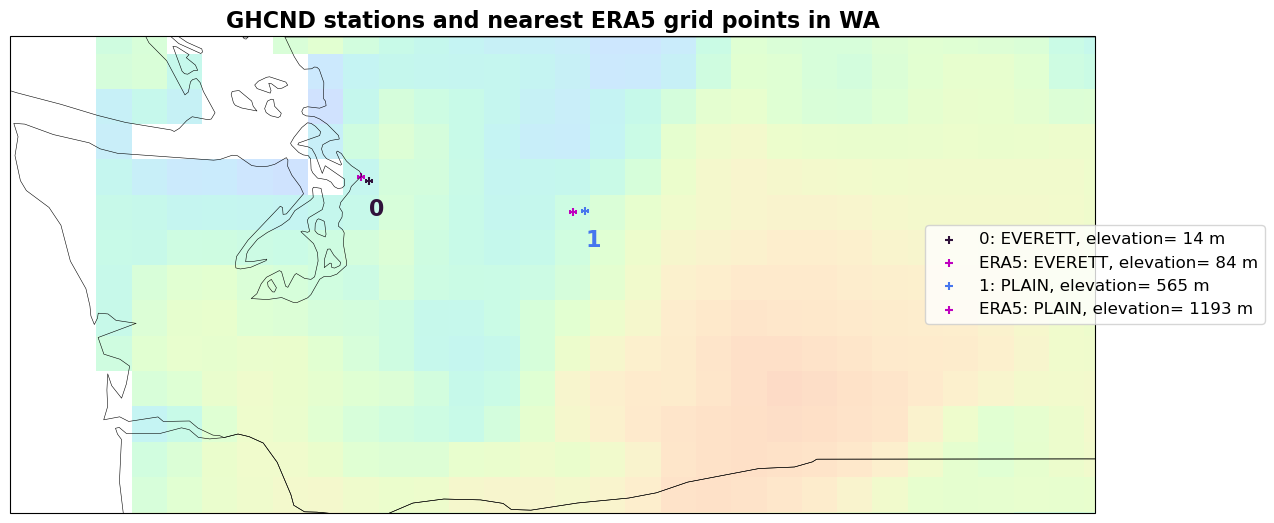

Processing state: CA
station MOUNT HAMILTON is at lon: -121.63473, lat: 37.34336
Nearest valid ERA5 point is at lon: -121.75, lat: 37.25
station NAPA STATE HOSPITAL is at lon: -122.2647, lat: 38.2777
Nearest valid ERA5 point is at lon: -122.25, lat: 38.25


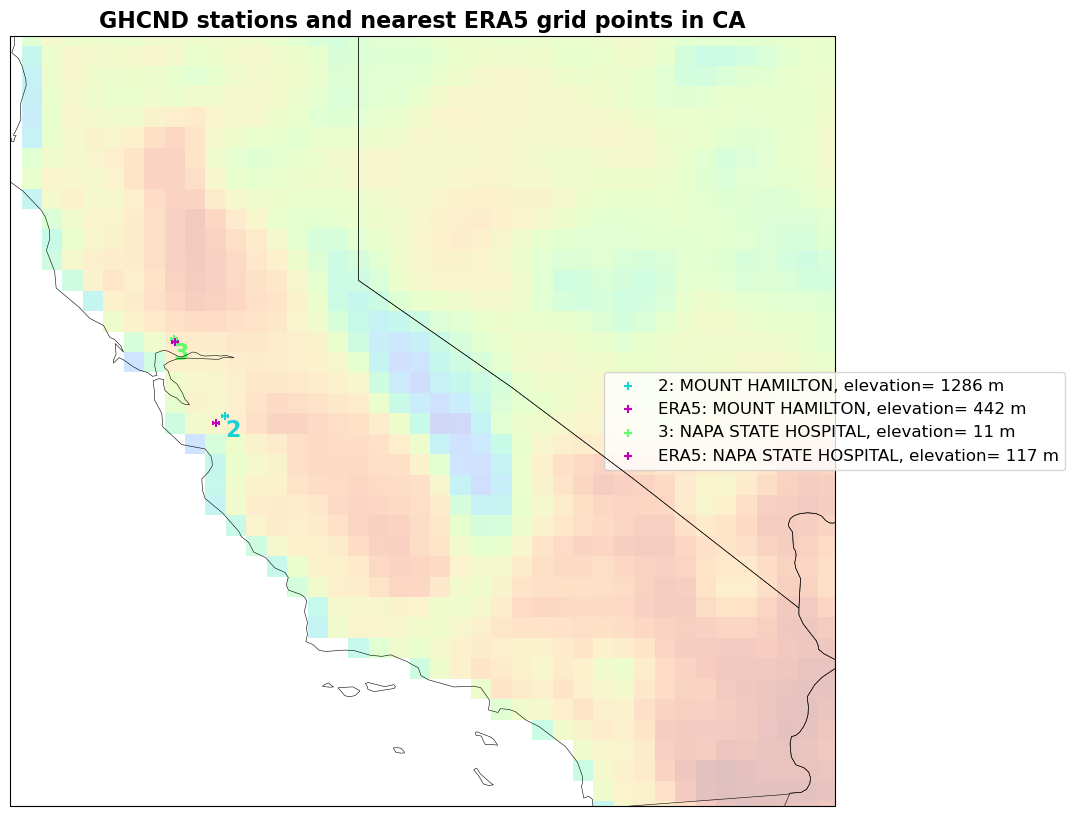

Processing state: AZ
station TOMBSTONE is at lon: -110.0686, lat: 31.7119
Nearest valid ERA5 point is at lon: -110.0, lat: 31.75
station NOGALES 6 N is at lon: -110.968, lat: 31.4554
Nearest valid ERA5 point is at lon: -111.0, lat: 31.5


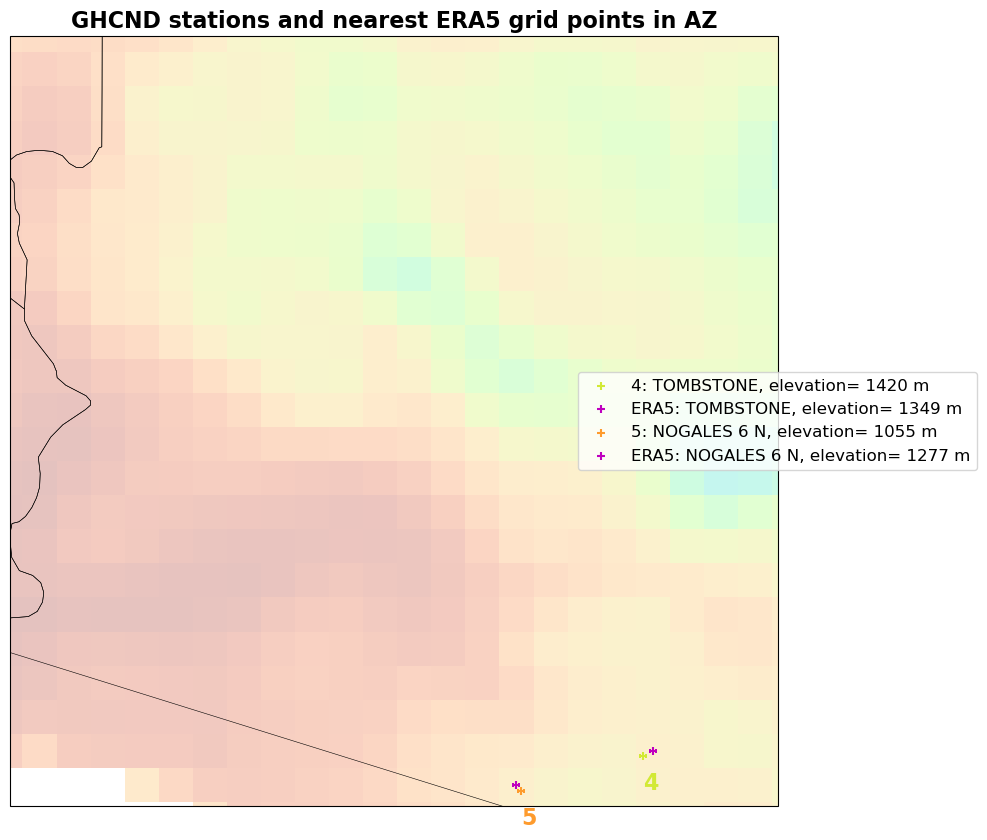

Processing state: NY
station RIVERHEAD RESEARCH FARM is at lon: -72.71612, lat: 40.96245
Nearest valid ERA5 point is at lon: -73.0, lat: 41.0
station PORT JERVIS is at lon: -74.6905, lat: 41.3891
Nearest valid ERA5 point is at lon: -74.75, lat: 41.5


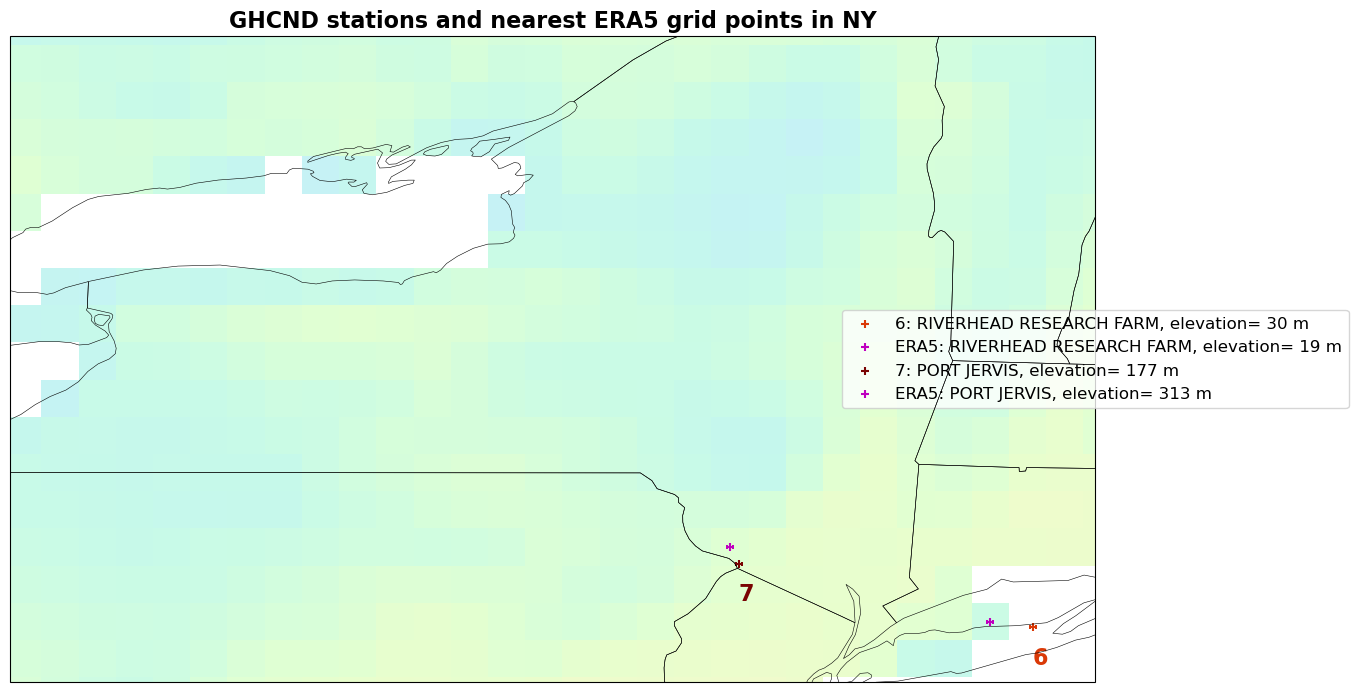

In [237]:
radius = 1.0
colors=cm.get_cmap('turbo',len(Tstations))
ij=0
vals,idx = np.unique(Tstates, return_index=True)
for istate in vals[np.argsort(idx)]:
  print(f'Processing state: {istate}')
  Tstations_state = [station for station, state in zip(Tstations, Tstates) if state == istate]
  
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,10),subplot_kw={'projection':ccrs.PlateCarree()})
  fig.subplots_adjust(hspace=1.15)
  ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  dsae['TXx'].mean('time').plot(ax=ax,cmap='turbo',add_colorbar=False,alpha=0.25)
  for istation in Tstations_state:
    ilon = longitude.sel(station=istation).data
    ilat = latitude.sel(station=istation).data
    iname = name.sel(station=istation).data.item().split(',')[0]
    ielevation = elevation.sel(station=istation).data.item()
    if not dsae['TXx'].sel(lon=slice(ilon-radius, ilon+radius), lat=slice(ilat-radius, ilat+radius)).mean('time').isnull().all():
      valid_ERA5 = find_nearest_valid(dsae['TXx'], ilon, ilat, radius=radius)
      lonera5=valid_ERA5["lon"].values[0].item()
      latera5=valid_ERA5["lat"].values[0].item()
      hgt_ERA5 = era5hgt['hgt'].sel(lon=lonera5, lat=latera5)
      print(f'station {iname} is at lon: {ilon}, lat: {ilat}')
      print(f'Nearest valid ERA5 point is at lon: {valid_ERA5["lon"].values[0].item()}, lat: {valid_ERA5["lat"].values[0].item()}')

    ax.scatter(ilon,ilat,marker='+',s=40,color=colors(ij),label=f'{ij}: {iname}, elevation= {ielevation:.0f} m')  
    ax.scatter(lonera5,latera5,marker='+',s=40,color='m',label=f'ERA5: {iname}, elevation= {hgt_ERA5.data.item():.0f} m')  
    ax.text(ilon,ilat-0.25,ij,color=colors(ij),fontsize=16,fontweight='bold')
    ij = ij + 1
  if istate == 'WA':
    ax.set_extent([-124.73694, -117.04768, 45.61901, 49.0], crs=ccrs.PlateCarree())     
  elif istate == 'CA':
    ax.set_extent([-124.2661, -114.17137, 32.56797, 41.9919], crs=ccrs.PlateCarree())
  elif istate == 'AZ':
    ax.set_extent([-114.71667, -109.08333, 31.345, 36.9953], crs=ccrs.PlateCarree())
  elif istate == 'NY':
    ax.set_extent([-79.58556, -72.2977, 40.59389, 44.93341], crs=ccrs.PlateCarree())   
  ax.set_title(f'GHCND stations and nearest ERA5 grid points in {istate}',fontsize=16,fontweight='bold')  
  plt.legend(loc='center',fontsize=12,bbox_to_anchor=(1., 0.5), borderaxespad=0.)
  plt.show()

**Figure caption.** Map of selected GHCND stations (marked with magenta plus signs) overlaid on the mean location parameter from ERA5-derived GEV fits. Station indices are labeled to identify each location in the analysis domain.

### Model Specification

Define the fevd (Fit an Extreme Value Distribution) formula with linear location and scale parameters as functions of GLOST climate covariate. 

In [224]:
%R fevd_options <- "type='GEV', method='MLE', initial = initial_vals, location.fun = ~ glost, scale.fun = ~ glost"

array(["type='GEV', method='MLE', initial = initial_vals, location.fun = ~ glost, scale.fun = ~ glost"],
      dtype='<U93')

In [225]:
compute_CI = True # Turn on Confidence Interval computation

In [226]:
print(datetime.datetime.now())

2026-09-10 12:13:10.076221


### Main Processing Loop: Station-by-Station GEV Fitting

For each selected GHCND station, extract the TXx time series, compare with ERA5 nearest-neighbor values, fit GEV distributions with GLOST covariate, perform 5-fold cross-validation for model diagnostics, compute bootstrap confidence intervals (optional), and populate the output arrays with estimates and uncertainty measures.

#########################################
Processing station EVERETT, WA US at lon=-122.195, lat=47.97528, elevation=14 m
Nearest valid ERA5 point is at lon= -122.25, lat= 48.0, elevation= 84 m
#########################################


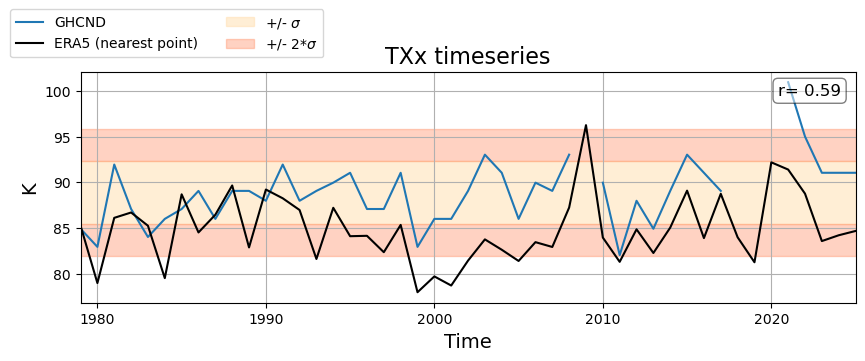

GEV model fitted: GHCND data


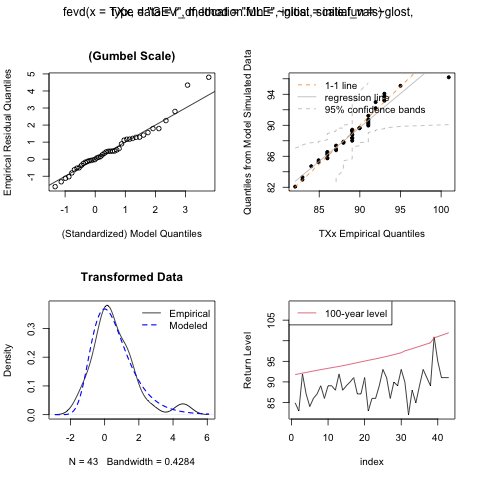

GEV model fitted: ERA5 data


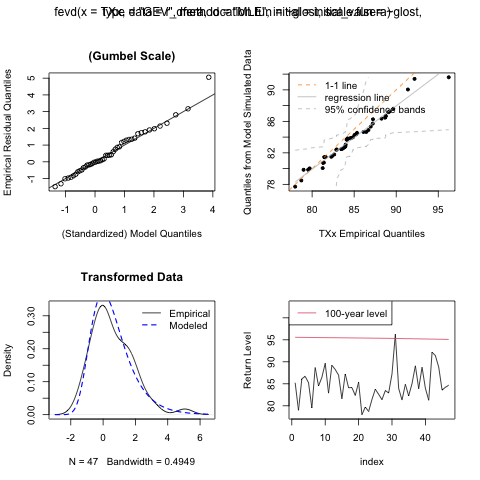

#########################################
Processing station PLAIN, WA US at lon=-120.65881, lat=47.75838, elevation=565 m
Nearest valid ERA5 point is at lon= -120.75, lat= 47.75, elevation= 1193 m
#########################################


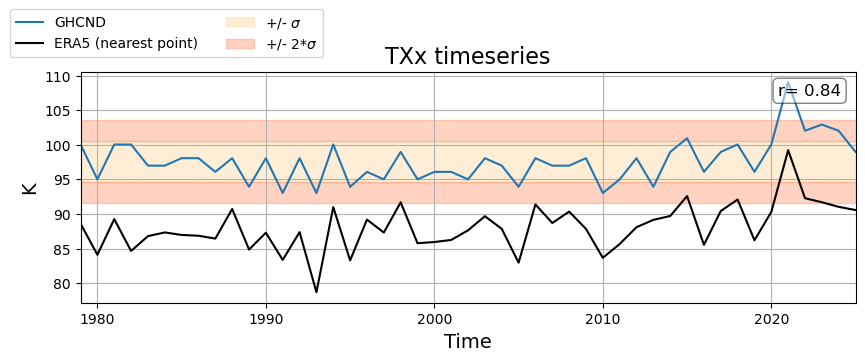

GEV model fitted: GHCND data


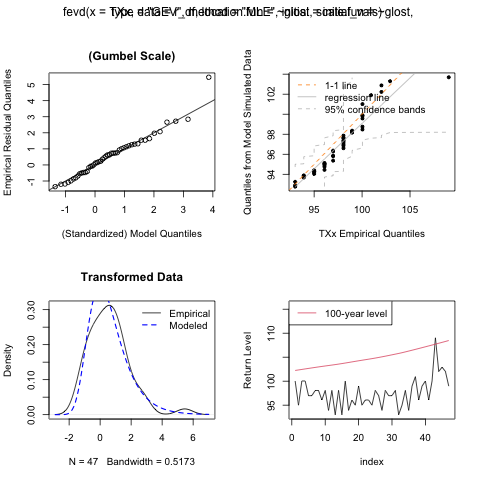

GEV model fitted: ERA5 data


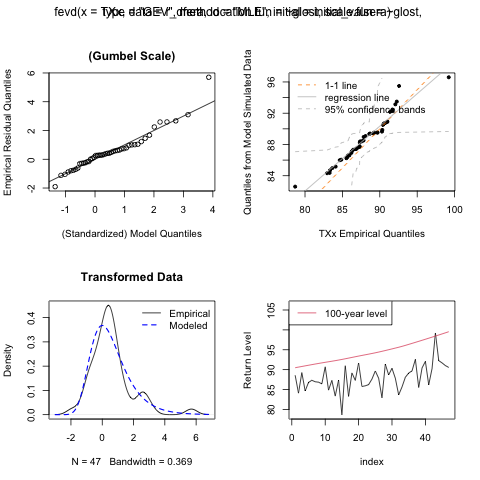

#########################################
Processing station MOUNT HAMILTON, CA US at lon=-121.63473, lat=37.34336, elevation=1286 m
Nearest valid ERA5 point is at lon= -121.75, lat= 37.25, elevation= 442 m
#########################################


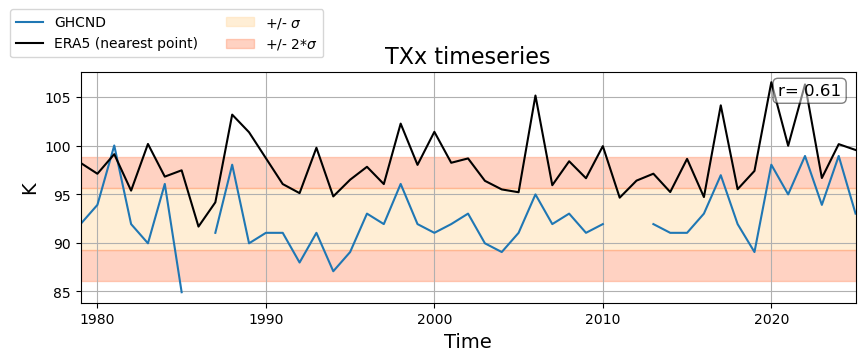

GEV model fitted: GHCND data


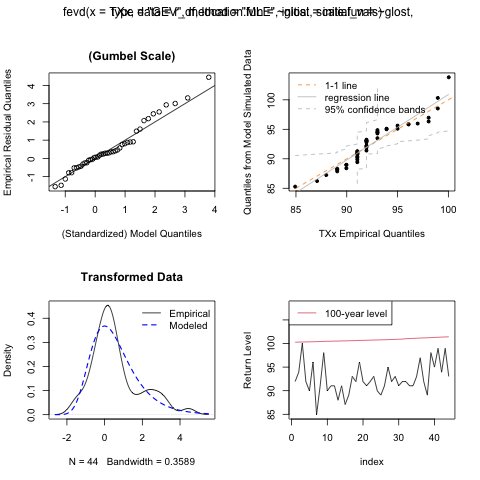

GEV model fitted: ERA5 data


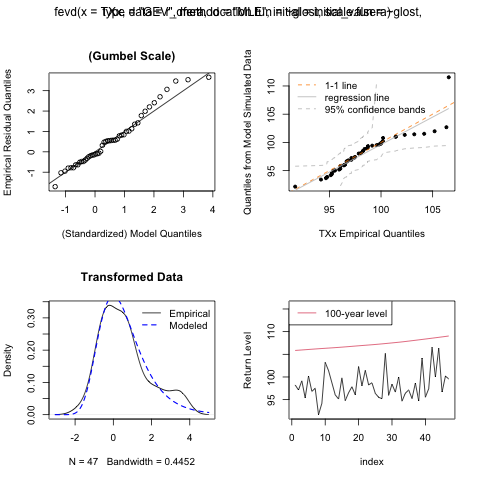

#########################################
Processing station NAPA STATE HOSPITAL, CA US at lon=-122.2647, lat=38.2777, elevation=11 m
Nearest valid ERA5 point is at lon= -122.25, lat= 38.25, elevation= 117 m
#########################################


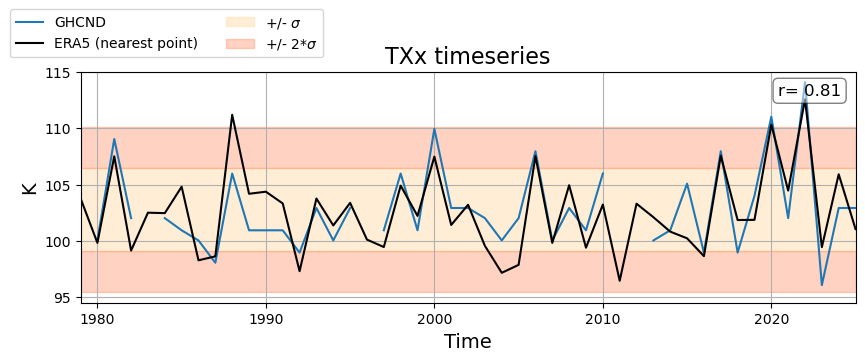

GEV model fitted: GHCND data


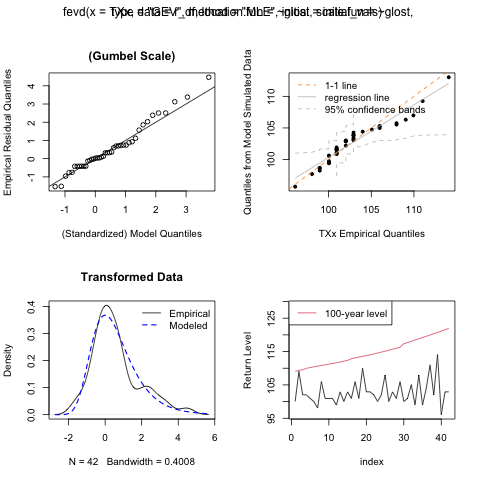

GEV model fitted: ERA5 data


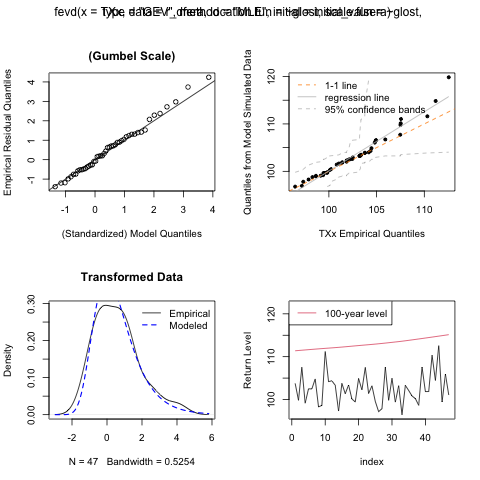

#########################################
Processing station TOMBSTONE, AZ US at lon=-110.0686, lat=31.7119, elevation=1420 m
Nearest valid ERA5 point is at lon= -110.0, lat= 31.75, elevation= 1349 m
#########################################


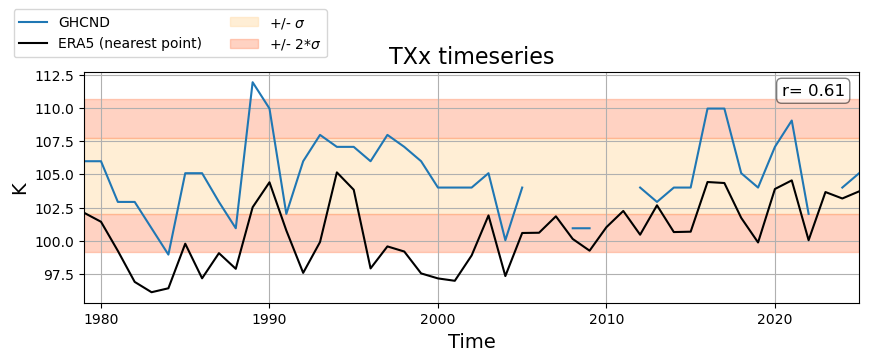

GEV model fitted: GHCND data


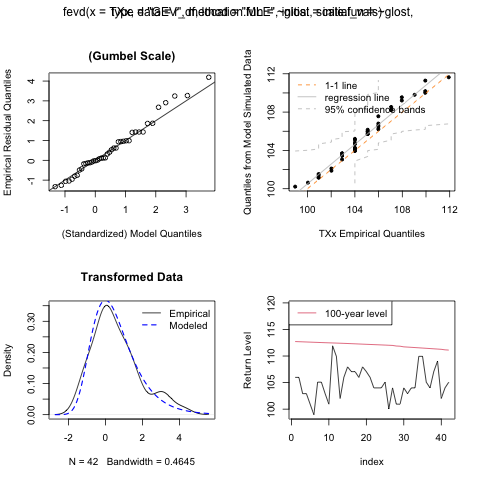

GEV model fitted: ERA5 data


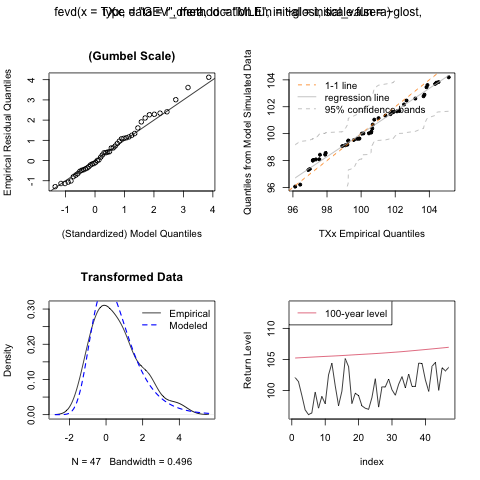

#########################################
Processing station NOGALES 6 N, AZ US at lon=-110.968, lat=31.4554, elevation=1055 m
Nearest valid ERA5 point is at lon= -111.0, lat= 31.5, elevation= 1277 m
#########################################


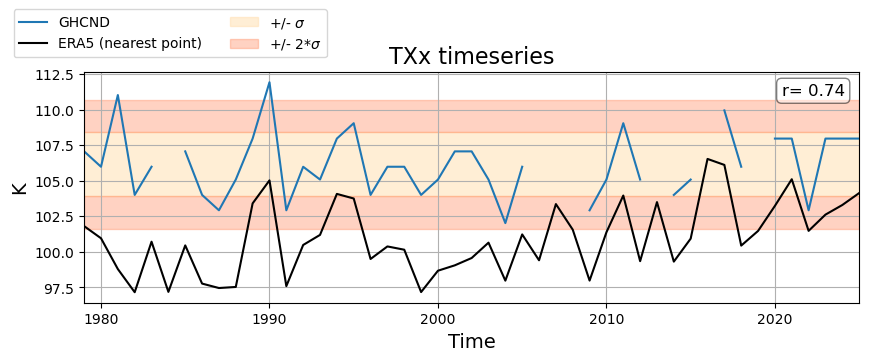

GEV model fitted: GHCND data


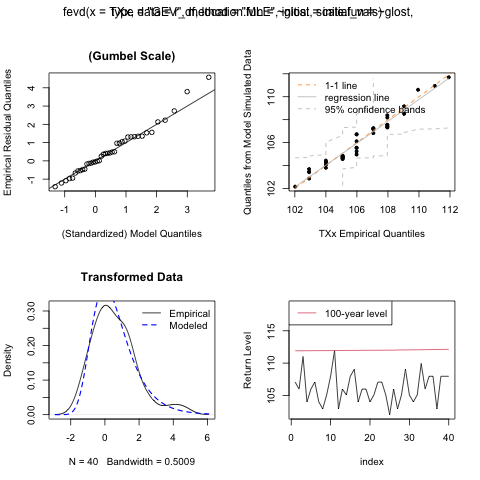

GEV model fitted: ERA5 data


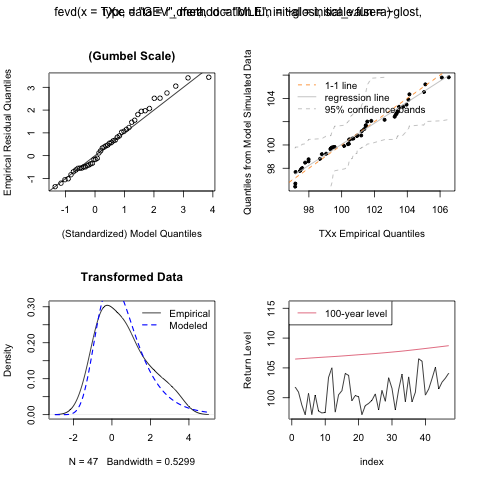

#########################################
Processing station RIVERHEAD RESEARCH FARM, NY US at lon=-72.71612, lat=40.96245, elevation=30 m
Nearest valid ERA5 point is at lon= -73.0, lat= 41.0, elevation= 19 m
#########################################


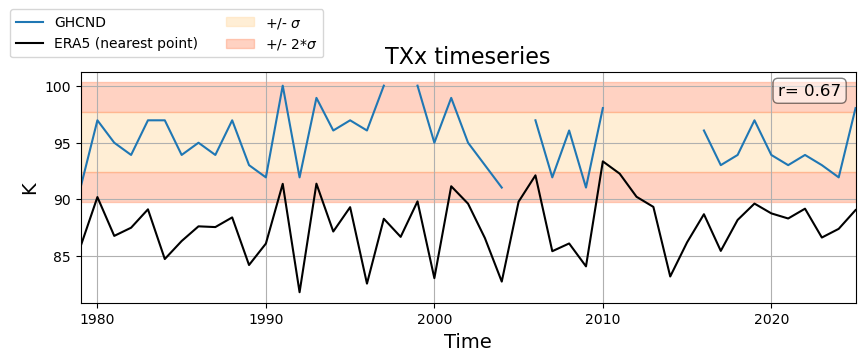

GEV model fitted: GHCND data


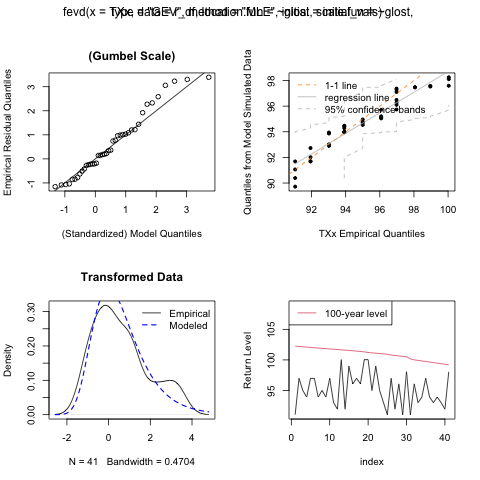

GEV model fitted: ERA5 data


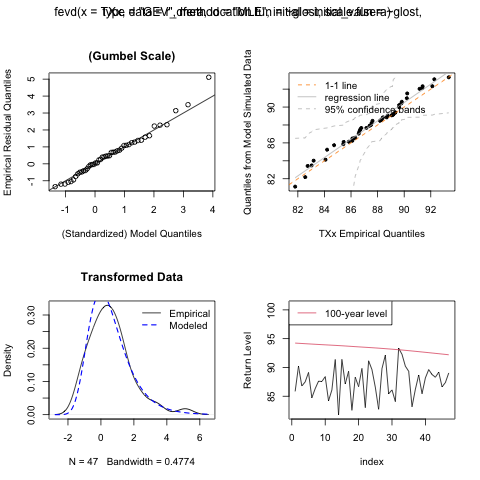

#########################################
Processing station PORT JERVIS, NY US at lon=-74.6905, lat=41.3891, elevation=177 m
Nearest valid ERA5 point is at lon= -74.75, lat= 41.5, elevation= 313 m
#########################################


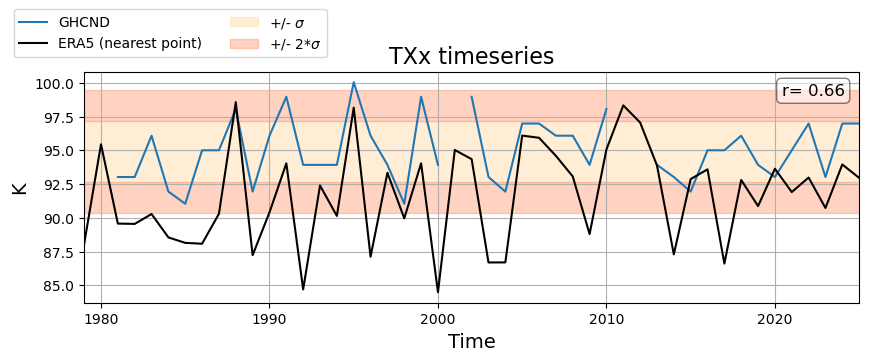

GEV model fitted: GHCND data


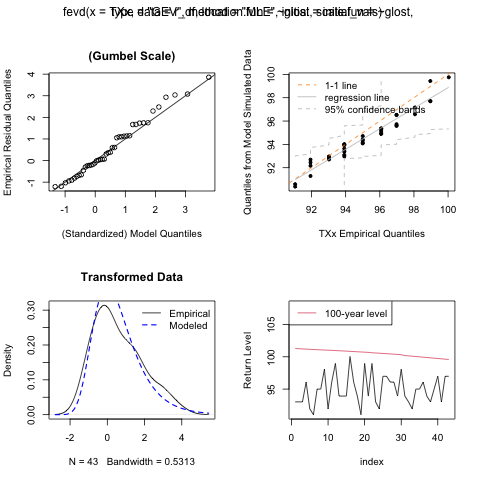

GEV model fitted: ERA5 data


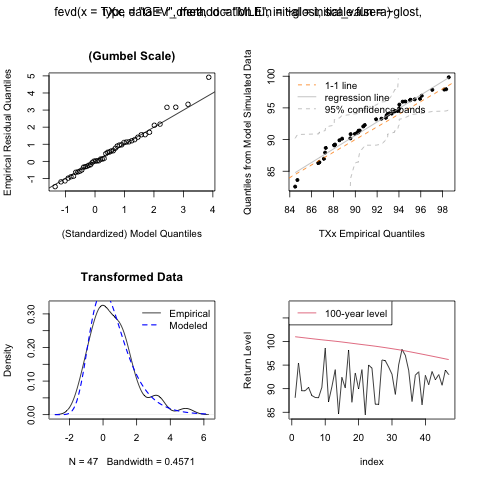

In [227]:

for ij in range(0,len(Tstations)):
  #for ij in range(2,3):
  ilon = longitude.sel(station = Tstations[ij]).data
  ilat = latitude.sel(station = Tstations[ij]).data
  # Extract values for boxes
  dsij = ds.sel(station = Tstations[ij])
  df = dsij.to_dataframe()
  df = df.reset_index()
  radius = 1.0 # degrees
  print('#########################################')  
  print(f'Processing station {dsij.name.data.item()} at lon={ilon}, lat={ilat}, elevation={elevation.sel(station = Tstations[ij]).data.item():.0f} m')

  x = dsij['time']
  y1 = dsij['TXx'].mean('time')-dsij['TXx'].std('time')
  y2 = dsij['TXx'].mean('time')+dsij['TXx'].std('time')
  y3 = dsij['TXx'].mean('time')-2*dsij['TXx'].std('time')
  y4 = dsij['TXx'].mean('time')+2*dsij['TXx'].std('time')
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,3))
  dsij['TXx'].plot(ax=ax, label='GHCND')
  if not dsae['TXx'].sel(lon=slice(ilon-radius, ilon+radius), lat=slice(ilat-radius, ilat+radius)).mean('time').isnull().all():
    valid_ERA5 = find_nearest_valid(dsae['TXx'], ilon, ilat, radius = radius)
    txx_era5 = valid_ERA5.to_xarray()['TXx']
    lonera5=valid_ERA5["lon"].values[0].item()
    latera5=valid_ERA5["lat"].values[0].item()
    hgt_ERA5 = era5hgt['hgt'].sel(lon=lonera5, lat=latera5)
    print(f'Nearest valid ERA5 point is at lon= {lonera5}, lat= {latera5}, elevation= {hgt_ERA5.data.item():.0f} m')
  print('#########################################')  

  ax.plot(dsij['time'], txx_era5, color='k', ls='-', linewidth=1.5, label='ERA5 (nearest point)')  
  ax.fill_between(x, y1, y2, color='navajowhite', alpha=0.5,label='+/- $\sigma$')
  ax.fill_between(x, y2, y4, color='coral', alpha=0.35,label='+/- 2*$\sigma$')
  ax.fill_between(x, y1, y3, color='coral', alpha=0.35)
  ax.set_ylabel(f'{units}',fontsize=14)
  ax.set_xlabel('Time',fontsize=14)
  ax.grid()
  # set y axis lim
  ax.set_xlim(x.min(),x.max())
  # show legend
  ax.legend(loc='upper left',ncol=2,bbox_to_anchor=(-0.1,1.3),prop={'size': 10})
  ###
  mask = ~np.isnan(dsij['TXx'].values) & ~np.isnan(txx_era5.values)
  correlation = np.corrcoef(dsij['TXx'].values[mask], txx_era5.values[mask])[0, 1]
  ax.text(0.9, 0.95, f'r= {correlation:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
  ###
  ax.set_title(f'TXx timeseries',fontsize=16)
  plt.show()

  dfera = txx_era5.to_dataframe().reset_index()
  dfera['time'] = df['time']
  dfera['glost'] = df['glost']

  df = df.assign(cell=1)
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave = df[df['TXx'].isna()]
  df = df[df['TXx'].notna()]

  itime = df['time'].values
  ntime = len(itime)

  loc_init = df['TXx'].mean()
  scale_init = df['TXx'].std()
  shape_init = 0.01

  loc_initera = dfera['TXx'].mean()
  scale_initera = dfera['TXx'].std()

  glost = ann_glost.sel(time=slice(yearb,yeare)).to_dataframe().reset_index()
  dftime = np.arange(yearb,yeare+1)
  %R -i ntime,loc_init,scale_init,shape_init,glost
  %R -i dfera,loc_initera,scale_initera

  if df.empty == False: 
    # Convert xarray to pandas DataFrame to R data.frame
    # You can now work with 'r_df' in R

    with (ro.default_converter + pandas2ri.converter).context():
      r_df = ro.conversion.get_conversion().py2rpy(df)
      r_dfera = ro.conversion.get_conversion().py2rpy(dfera)
    globalenv['r_df'] = r_df
    globalenv['r_dfera'] = r_dfera
    #%R names(r_df)[names(r_df) == "time"] <- "year"
    # Extremes GEV model fitting  
    %R initial_vals <- list(location = loc_init, scale = scale_init, shape = shape_init)
    %R call_fevd <- paste("fevd(TXx, data = r_df,",fevd_options,")")
    %R m_gev <- eval(parse(text = call_fevd))
    print('GEV model fitted: GHCND data')
    %R plot(m_gev,rp=c(100))

    print('GEV model fitted: ERA5 data')
    %R initial_valsera <- list(location = loc_initera, scale = scale_initera, shape = shape_init)
    %R m_gevera <- fevd(TXx, data = r_dfera, type='GEV', method='MLE', initial = initial_valsera, location.fun = ~ glost, scale.fun = ~ glost)
    %R plot(m_gevera,rp=c(100))

    %R m_gevL <- fevd(TXx, data = r_df,type='GEV',method='MLE', initial = initial_vals, location.fun= ~ glost)
    %R m_gevS <- fevd(TXx, data = r_df,type='GEV',method='MLE', initial = initial_vals )

    %R pp <- summary(m_gev, silent = TRUE)
    %R rpvalueL <- lr.test(m_gevS, m_gevL)$p.value
    %R rpvalueS <- lr.test(m_gevL, m_gev)$p.value
    %R -o rpvalueL,rpvalueS

    #%R loc <- findpars(m_gev)$location
    #%R sca <- findpars(m_gev)$scale
    #%R sha <- findpars(m_gev)$shape
    %R loc <- pp$par[['mu0']] + pp$par[['mu1']]*glost$GLOST
    %R sca <- pp$par[['sigma0']] + pp$par[['sigma1']]*glost$GLOST
    %R sha <- rep(pp$par[['shape']],times =length(glost$GLOST))
    %R rAIC <- pp$AIC
    %R rBIC <- pp$BIC
    %R -o loc,sca,sha,rAIC,rBIC

    if sca.all() > 0.:
        %R v <- make.qcov(m_gev,vals=list(mu1=glost$GLOST,sigma1=glost$GLOST))
        %R gev_rl <- return.level(m_gev, return.period = rp, qcov = v)
        %R -o gev_rl
        
        ######
        # Cross-Validation
        ######
        %R splits <- rep(1:K,times =ceiling(ntime/K))[1:ntime]
        #%R splits[as.integer(ntime-5):ntime] <- 0
        %R tests_scores <- cross_validation(r_df,fevd_options,K)
        %R ktime <- tests_scores$scores_cv$time
        %R df_ks_cvm <- tests_scores$tests
        %R SE <- tests_scores$scores_cv$SE
        %R DawSeb <- tests_scores$scores_cv$DawSeb
        %R CRPS <- tests_scores$scores_cv$CRPS      
        %R rAIC_cv <- tests_scores$AIC_cv
        %R rBIC_cv <- tests_scores$BIC_cv
        %R -o ktime,SE,DawSeb,CRPS,df_ks_cvm,rAIC_cv,rBIC_cv

        ######
        # Confidence Intervals
        ######
        if compute_CI == True:
          %R boot <- extremes_bootGE_LS(m_gev,r_df,fevd_options,n,0.1,rp,glost)
          %R DLoc_qr <- boot$Dloc_q
          %R DScale_qr <- boot$Dsca_q
          %R DRL_qr <- boot$DRL_q
          %R Loc_qr <- boot$loc_q
          %R Scale_qr <- boot$sca_q
          %R RL_qr <- boot$RL_q
          %R -o DLoc_qr,DScale_qr,DRL_qr,Loc_qr,Scale_qr,RL_qr

        ######
        # Write output
        ######
        data.loc[{'time':itime,'station':Tstations[ij]}] = df['TXx'].values 
        covariate.loc[{'time':itime,'station':Tstations[ij]}] = df['glost'].values

        location.loc[{'time':dftime,'station':Tstations[ij]}] = loc
        scale.loc[{'time':dftime,'station':Tstations[ij]}] = sca
        shape.loc[{'time':dftime,'station':Tstations[ij]}] = sha
        for irp in range(0,len(return_periods)):
          rl.loc[{'time':dftime,'station':Tstations[ij],'return_periods':return_periods[irp]}] = gev_rl[:,irp]
        AIC.loc[{'station':Tstations[ij]}] = rAIC.item()
        BIC.loc[{'station':Tstations[ij]}] = rBIC.item()
        pvalueL.loc[{'station':Tstations[ij]}] = rpvalueL.item()
        pvalueS.loc[{'station':Tstations[ij]}] = rpvalueS.item()

        # CV
        SE_cv.loc[{'time':ktime,'station':Tstations[ij]}] = SE
        DawSeb_cv.loc[{'time':ktime,'station':Tstations[ij]}] = DawSeb
        CRPS_cv.loc[{'time':ktime,'station':Tstations[ij]}] = CRPS
        KS_D_cv.loc[{'time':ktime,'station':Tstations[ij]}] = df_ks_cvm['KS_D'].values
        KS_pvalue_cv.loc[{'time':ktime,'station':Tstations[ij]}] = df_ks_cvm['KS_pvalue'].values
        CVM_D_cv.loc[{'time':ktime,'station':Tstations[ij]}] = df_ks_cvm['CVM_D'].values
        CVM_pvalue_cv.loc[{'time':ktime,'station':Tstations[ij]}] = df_ks_cvm['CVM_pvalue'].values
        AIC_cv.loc[{'station':Tstations[ij]}] = rAIC_cv
        BIC_cv.loc[{'station':Tstations[ij]}] = rBIC_cv

        # CI
        itime = df['time'].values
        if compute_CI == True:
          Dlocation_q.loc[{'station':Tstations[ij]}] = DLoc_qr[0,:].T
          Dscale_q.loc[{'station':Tstations[ij]}] = DScale_qr[0,:].T
          location_q.loc[{'time':dftime,'station':Tstations[ij]}] = Loc_qr.T
          scale_q.loc[{'time':dftime,'station':Tstations[ij]}] = Scale_qr.T
          for irp in range(0,len(return_periods)):
            Drl_q.loc[{'station':Tstations[ij],'return_periods':return_periods[irp]}] = DRL_qr[irp,:]
            rl_q.loc[{'time':dftime,'station':Tstations[ij],'return_periods':return_periods[irp]}] = RL_qr.reshape(len(return_periods),len(dftime),3)[irp,:,:].T




**Figure caption (per station).** Top figure: Annual Maximum Daily Temperature (TXx) time series for each GHCND station, with comparison to the ERA5 nearest-neighbor point. Shaded bands represent ±1σ and ±2σ variability around the mean. The correlation coefficient between GHCND and ERA5 TXx is displayed in the upper-right corner of each plot.
Bottom figure: Diagnostics from the GEV df fitted to the TXx data shown above. Quantile-quantile plot (top left) quantiles from a sample drawn from the fitted GEV df against the empirical data quantiles with 95% confidence bands (top right), density plots of empirical data and fitted GEV df (bottom left), and TXx are plotted as a line along with associated effective return levels for return periods of 100 years (bottom right).

In [228]:
# ------------------------------------------------------------------
# Output variable attributes
# ------------------------------------------------------------------
data.attrs.update({
    'long_name': 'Annual maximum temperature from GHCND station',
    'standard_name': 'air_temperature',
    'units': units,
    'description': 'Annual maximum daily temperature time series from GHCND stations used in the GEV analysis'
})

covariate.attrs.update({
    'long_name': 'LOESS-smoothed NOAA Global Land and Ocean Surface Temperature (GLOST)',
    'units': units_cov,
    'description': 'long-term global temperature variability covariate used in the GEV location and scale parameter'
})

location.attrs.update({
    'long_name': 'GEV location parameter',
    'units': units,
    'description': 'Estimated location parameter of the fitted GEV distribution'
})

scale.attrs.update({
    'long_name': 'GEV scale parameter',
    'units': units,
    'description': 'Estimated scale parameter of the fitted GEV distribution'
})

shape.attrs.update({
    'long_name': 'GEV shape parameter',
    'units': '1',
    'description': 'Estimated shape parameter of the fitted GEV distribution'
})

rl.attrs.update({
    'long_name': 'Return level',
    'units': units,
    'description': 'Return level estimates for annual maximum temperature by return period'
})

AIC.attrs.update({
    'long_name': 'AIC',
    'units': '1',
    'description': 'Akaike Information Criterion for the fitted GEV model'
})

BIC.attrs.update({
    'long_name': 'BIC',
    'units': '1',
    'description': 'Bayesian Information Criterion for the fitted GEV model'
})

pvalueL.attrs.update({
    'long_name': 'Likelihood ratio p-value',
    'units': '1',
    'description': 'p-value comparing the covariate GEV model with the no-covariate model'
})

pvalueS.attrs.update({
    'long_name': 'Scale parameter p-value',
    'units': '1',
    'description': 'p-value associated with the scale comparison test'
})

location_q.attrs.update({
    'long_name': 'GEV location parameter confidence interval',
    'units': units,
    'description': '5th, median, and 95th quantiles of the location parameter'
})

scale_q.attrs.update({
    'long_name': 'GEV scale parameter confidence interval',
    'units': units,
    'description': '5th, median, and 95th quantiles of the scale parameter'
})

rl_q.attrs.update({
    'long_name': 'Return level confidence interval',
    'units': units,
    'description': '5th, median, and 95th quantiles of return level estimates by return period'
})

Dlocation_q.attrs.update({
    'long_name': 'Difference in location parameter',
    'units': units,
    'description': 'Change in GEV location parameter relative to the first year in the record'
})

Dscale_q.attrs.update({
    'long_name': 'Difference in scale parameter',
    'units': units,
    'description': 'Change in GEV scale parameter relative to the first year in the record'
})

Drl_q.attrs.update({
    'long_name': 'Difference in return level',
    'units': units,
    'description': 'Change in return level relative to the first year in the record'
})

SE_cv.attrs.update({
    'long_name': 'SE score',
    'units': units,
    'description': f'{K}-fold Cross-validation SE score'
})

DawSeb_cv.attrs.update({
    'long_name': 'Daw-Seb score',
    'units': '1',
    'description': f'{K}-fold Cross-validation Daw-Seb score'
})

CRPS_cv.attrs.update({
    'long_name': 'CRPS score',
    'units': units,
    'description': f'{K}-fold Cross-validation CRPS score'
})

KS_D_cv.attrs.update({
    'long_name': 'KS statistic',
    'units': '1',
    'description': f'Kolmogorov-Smirnov test statistic from the {K}-fold cross-validation'
})

KS_pvalue_cv.attrs.update({
    'long_name': 'KS p-value',
    'units': '1',
    'description': f'Kolmogorov-Smirnov p-value from the {K}-fold cross-validation'
})

CVM_D_cv.attrs.update({
    'long_name': 'Cramér-von Mises statistic',
    'units': '1',
    'description': f'Cramér-von Mises test statistic from the {K}-fold cross-validation'
})

CVM_pvalue_cv.attrs.update({
    'long_name': 'Cramér-von Mises p-value',
    'units': '1',
    'description': 'Cramér-von Mises p-value from cross-validation'
})

AIC_cv.attrs.update({
    'long_name': 'Cross-validation AIC',
    'units': '1',
    'description': f'AIC values from the {K}-fold cross-validation'
})

BIC_cv.attrs.update({
    'long_name': 'Cross-validation BIC',
    'units': '1',
    'description': f'BIC values from the {K}-fold cross-validation'
})

In [229]:
dsout=rl.to_dataset(name='rl')
dsout=dsout.merge({'location':location,'scale':scale,'shape':shape})
dsout=dsout.merge({'data':data,'covariate':covariate})
dsout=dsout.merge({'AIC':AIC,'BIC':BIC,'pvalueL':pvalueL,'pvalueS':pvalueS})
#
if compute_CI == True:
  dsout=dsout.merge({'location_q':location_q})
  dsout=dsout.merge({'scale_q':scale_q})
  dsout=dsout.merge({'rl_q':rl_q})
  dsout=dsout.merge({'Difflocation_q':Dlocation_q})
  dsout=dsout.merge({'Diffscale_q':Dscale_q})
  dsout=dsout.merge({'Diffrl_q':Drl_q})
#
dsout=dsout.merge({'CRPS_cv':CRPS_cv})
dsout=dsout.merge({'DawSeb_cv':DawSeb_cv,'SE_cv':SE_cv})
dsout=dsout.merge({'KS_D_cv':KS_D_cv,'KS_pvalue_cv':KS_pvalue_cv,'CVM_D_cv':CVM_D_cv,'CVM_pvalue_cv':CVM_pvalue_cv})
dsout=dsout.merge({'AIC_cv':AIC_cv,'BIC_cv':BIC_cv})
#
dsout = dsout.merge({'elevation':ds.elevation,'name': ds.name,'state':ds.state,'GHCN_ID':ds.GHCN_ID,\
              'longitude':ds.longitude,'latitude':ds.latitude})
#


AttributeError: 'Dataset' object has no attribute 'state'

### Consolidate Results and Prepare NetCDF Output

Merge all fitted parameters, return levels, diagnostic metrics, cross-validation scores, and bootstrap-derived confidence intervals into a single xarray Dataset. Include station metadata (elevation, location, name, state, GHCN ID).

In [ ]:
dsout = dsout.sel(station=Tstations)

### Save Results to NetCDF File

Filter the dataset to include only the successfully processed stations and write the complete results to a NetCDF file for downstream analysis and visualization.

In [ ]:
# ------------------------------------------------------------------
# Dataset attributes
# ------------------------------------------------------------------
dsout.attrs.update({
    'title': 'GEV TXx return levels for CONUS GHCND stations with NOAA GLOST anomaly covariate',
    'summary': 'Annual maximum temperature return levels for CONUS GHCND stations fitted with a generalized extreme value model using NOAA GLOST anomaly covariate on the location and scale parameters.',
    'station_selection_method': 'Stations were selected if at least 70% of annual TXx observations were present during 1979-2025; selected stations were then used for the GEV analysis.',
    'model': 'GEV with covariate on location and scale parameters (method = MLE, location.fun = ~ glost, scale.fun = ~ glost)',
    'gev_software': 'R package extRemes',
    'gev_fitting_method': 'GEV fit performed using extRemes::fevd()',
    'confidence_interval_method': 'Percentile confidence intervals computed using extRemes::pbooter()',
    'confidence_interval_reference': 'E. Gilleland (November 2020) recommendation for bootstrap confidence intervals',
    'bootstrap_iterations': f'{n}',
    'covariate_name': 'glost',
    'covariate_description': 'NOAA GLOST anomaly',
    'covariate_units': units_cov,
    'temperature_units': units,
    'time_range': f'{yearb}-{yeare}',
    'return_periods': str(return_periods),
    'quantiles': str(Tquantile),
    'source': 'GHCND station annual maximum daily temperature plus NOAA GLOST anomaly',
    'created_by': 'Washington_TXx_GHCND_ij_glost_extRemes_gev.ipynb',
    'conventions': 'CF-1.8'
})

In [ ]:
outfile = f'/Users/gahe5417/data/TXx/{itest}{n}_{yearb}_{yeare}.nc'
if not os.path.exists(outfile):
  dsout.to_netcdf(outfile)
  print(f"Created {outfile}")
else:
  dsout.to_netcdf(outfile+'.nc')
  print(f"{outfile} already exists")

Created ~/data/TXx/Alaska_TXx_GHCND_ij_glostLocSca_extremes_gev_CV_CI300_1979_2025.nc
